In [1]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import os

In [3]:
# Load the dataset
cwd = os.getcwd()
df = pd.read_csv(cwd+"/togo-dapaong_qc.csv", parse_dates=['Timestamp'])
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [11]:
df.shape

(525600, 19)

In [4]:
# Descriptive stats for numeric columns
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


In [5]:
# Count missing values
df.isna().sum()

,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,0
RH,0
WS,0
WSgust,0


In [6]:
# Identify columns with more than 5% missing values (which there is none)
missing_percent = df.isna().mean() * 100
print("\n🔍 Columns with >5% missing values:")
print(missing_percent[missing_percent > 5])


🔍 Columns with >5% missing values:
Comments    100.0
dtype: float64


In [7]:
# 3. Outlier Detection & Basic Cleaning
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Fill missing values with median for selected columns
df[key_cols] = df[key_cols].apply(lambda col: col.fillna(col.median()))

In [8]:
# Compute Z-scores for outlier detection
z_scores = df[key_cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outlier_rows = outliers.any(axis=1)
print(f"\ Outliers Detected: {outlier_rows.sum()} rows")

\ Outliers Detected: 9251 rows


In [9]:
# Drop rows with outliers
df_clean = df[~outlier_rows].copy()

In [10]:
os.makedirs("/content/data", exist_ok=True)

In [12]:
# save the cleaned CSV
df_clean.to_csv("/content/data/togo_clean.csv", index=False)
print("✅ Cleaned data saved to /content/data/togo_clean.csv")

✅ Cleaned data saved to /content/data/togo_clean.csv


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


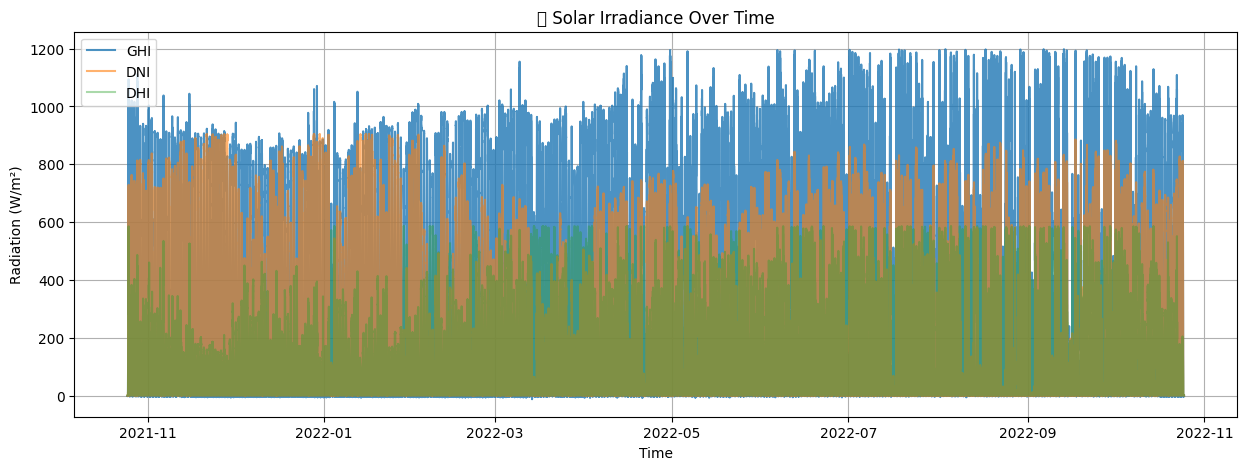

In [13]:
#  4. Time Series Analysis
# Visualize solar patterns and detect temporal trends

plt.figure(figsize=(15, 5))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI', alpha=0.8)
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI', alpha=0.6)
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI', alpha=0.4)
plt.xlabel("Time")
plt.ylabel("Radiation (W/m²)")
plt.title("📅 Solar Irradiance Over Time")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


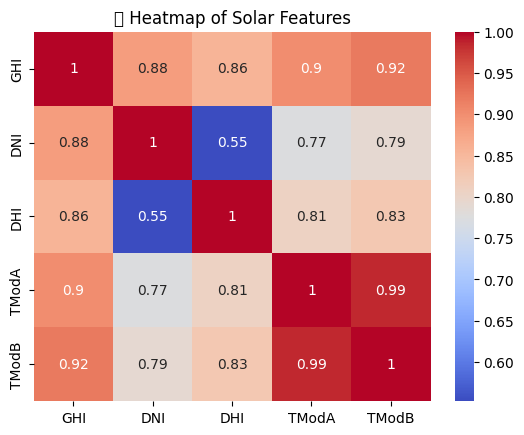

In [14]:
#  6. Correlation & Relationship Analysis
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("📊 Heatmap of Solar Features")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


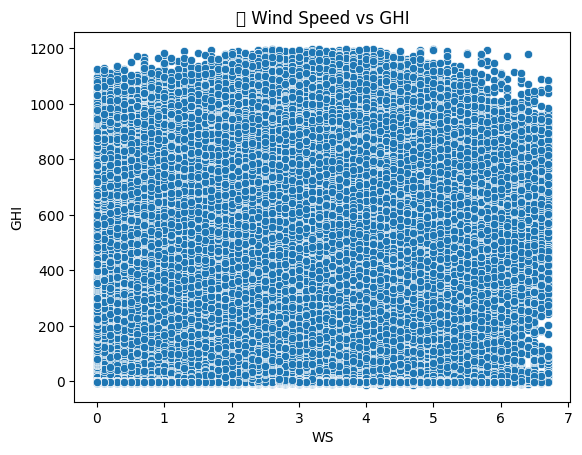

In [15]:
# Scatter plot examples
sns.scatterplot(data=df_clean, x='WS', y='GHI')
plt.title("💨 Wind Speed vs GHI")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


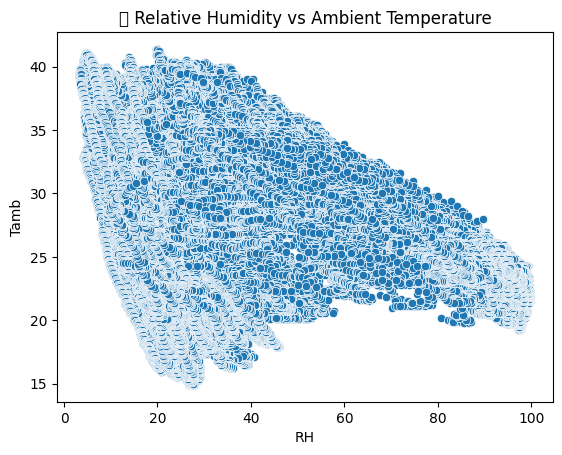

In [16]:
sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("🌡️ Relative Humidity vs Ambient Temperature")
plt.show()

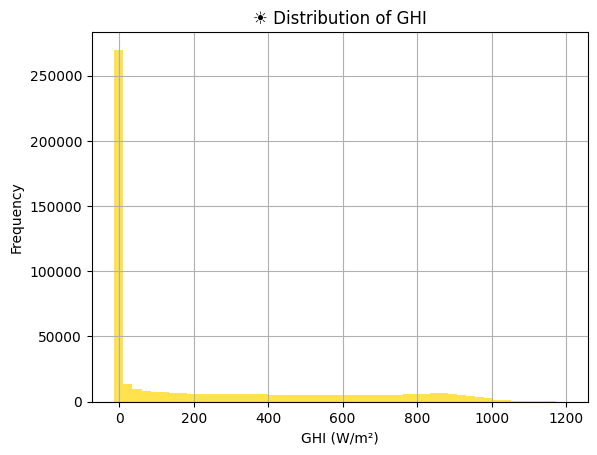

In [17]:
# 7. Wind & Distribution Analysis
# wind dynamics and variable distributions

# Histogram of GHI
plt.hist(df_clean['GHI'], bins=50, alpha=0.7, color='gold')
plt.title("☀️ Distribution of GHI")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127787 (\N{FOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


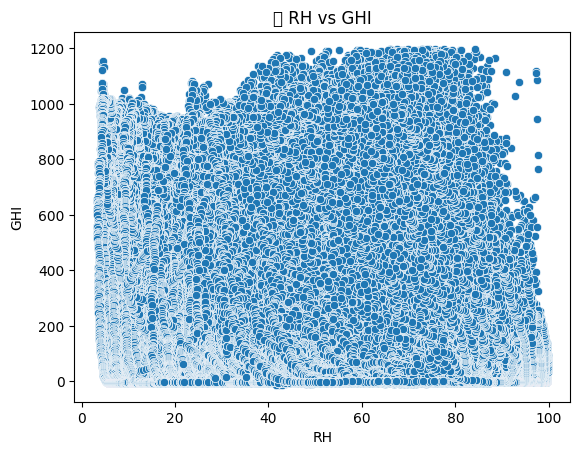

In [18]:
#  8. Temperature-Humidity Interaction
# Explore how RH may influence temp and solar radiation

sns.scatterplot(data=df_clean, x='RH', y='GHI')
plt.title("🌫️ RH vs GHI")
plt.show()

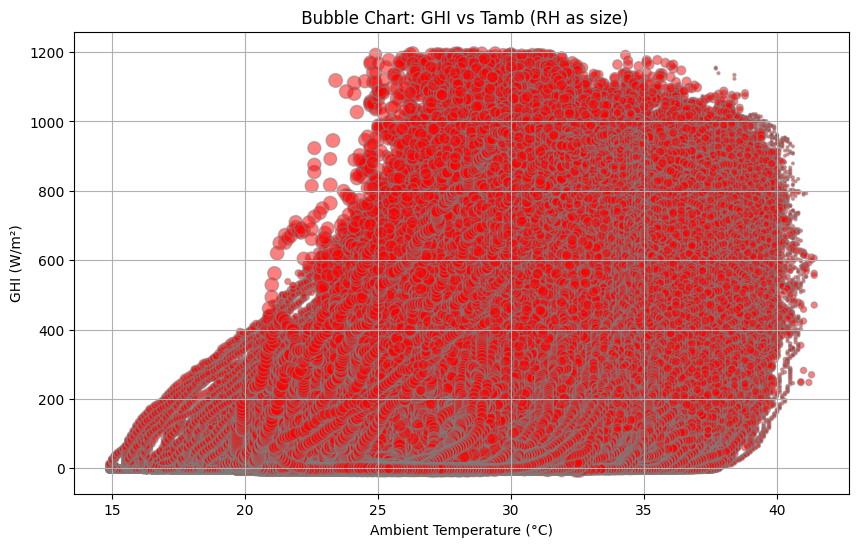

In [20]:
#  9. Bubble Chart: GHI vs Tamb with RH as size
plt.figure(figsize=(10, 6))
plt.scatter(
    df_clean['Tamb'], df_clean['GHI'],
    s=df_clean['RH'], alpha=0.5, c='red', edgecolors='gray')
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("GHI (W/m²)")
plt.title(" Bubble Chart: GHI vs Tamb (RH as size)")
plt.grid(True)
plt.show()